In [69]:
import shap 
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


In [70]:
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
list(df)

['Grade',
 'Project',
 'Case_ID',
 'Gender',
 'Age_at_diagnosis',
 'Primary_Diagnosis',
 'Race',
 'IDH1',
 'TP53',
 'ATRX',
 'PTEN',
 'EGFR',
 'CIC',
 'MUC16',
 'PIK3CA',
 'NF1',
 'PIK3R1',
 'FUBP1',
 'RB1',
 'NOTCH1',
 'BCOR',
 'CSMD3',
 'SMARCA4',
 'GRIN2A',
 'IDH2',
 'FAT4',
 'PDGFRA']

In [71]:
df = df.drop(columns=['Project', 'Case_ID', 'Primary_Diagnosis'])
df = df[~df['Gender'].isin(['--', 'not reported'])]
df = df[~df['Age_at_diagnosis'].isin(['--', 'not reported'])]
df = df[~df['Race'].isin(['--', 'not reported'])]

In [72]:
def parse_age(age_str):
    parts = age_str.split()
    years = int(parts[0])
    days = int(parts[2]) if len(parts) >= 4 else 0
    return round(years + days / 365.25, 2)

df['Age_at_diagnosis'] = df['Age_at_diagnosis'].apply(parse_age)

mutation_cols = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16',
                 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1',
                 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

In [73]:
for col in mutation_cols:
    df[col] = df[col].map({'MUTATED': 1, 'NOT_MUTATED': 0})

df['Grade'] = df['Grade'].map({'LGG': 0, 'GBM': 1})

print(df.shape)              
print(df['Grade'].value_counts())
print(df.dtypes)
print(df.isnull().sum())

(839, 24)
Grade
0    487
1    352
Name: count, dtype: int64
Grade                 int64
Gender               object
Age_at_diagnosis    float64
Race                 object
IDH1                  int64
TP53                  int64
ATRX                  int64
PTEN                  int64
EGFR                  int64
CIC                   int64
MUC16                 int64
PIK3CA                int64
NF1                   int64
PIK3R1                int64
FUBP1                 int64
RB1                   int64
NOTCH1                int64
BCOR                  int64
CSMD3                 int64
SMARCA4               int64
GRIN2A                int64
IDH2                  int64
FAT4                  int64
PDGFRA                int64
dtype: object
Grade               0
Gender              0
Age_at_diagnosis    0
Race                0
IDH1                0
TP53                0
ATRX                0
PTEN                0
EGFR                0
CIC                 0
MUC16               0
PIK3CA      

In [74]:
X = df.drop(columns=['Grade', 'Gender', 'Race'])
Y = df.Grade


In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=25)
clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 88.10%


In [76]:
explainer_lr  = shap.KernelExplainer(clf.predict_proba, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)

Using 671 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 168/168 [00:56<00:00,  2.97it/s]


In [77]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, Y, test_size=0.2, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train2, y_train2)
y_pred = classifier.predict(X_test2)
accuracy = accuracy_score(y_test2, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test2, y_pred)

Accuracy: 80.95%


In [78]:
background = shap.kmeans(X_train2, 50)
explainer_rf = shap.KernelExplainer(classifier.predict_proba, background)
shap_values_rf = explainer_rf.shap_values(X_test2)

100%|██████████| 168/168 [01:49<00:00,  1.53it/s]


In [79]:

X_train3, X_test3, y_train3, y_test3 = train_test_split(X, Y, test_size=0.2, random_state=42)
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}
model = XGBClassifier(**params)
model.fit(X_train3, y_train3)
y_pred3 = model.predict(X_test3)

accuracy = accuracy_score(y_test3, y_pred3)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test3, y_pred3))

Model Accuracy: 0.8690476190476191

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        89
           1       0.82      0.92      0.87        79

    accuracy                           0.87       168
   macro avg       0.87      0.87      0.87       168
weighted avg       0.88      0.87      0.87       168



In [80]:
background = shap.kmeans(X_train3, 50)
explainer_xgb = shap.KernelExplainer(lambda x: model.predict_proba(x), background)
shap_values_xgb = explainer_xgb.shap_values(X_test3)


100%|██████████| 168/168 [00:08<00:00, 19.88it/s]


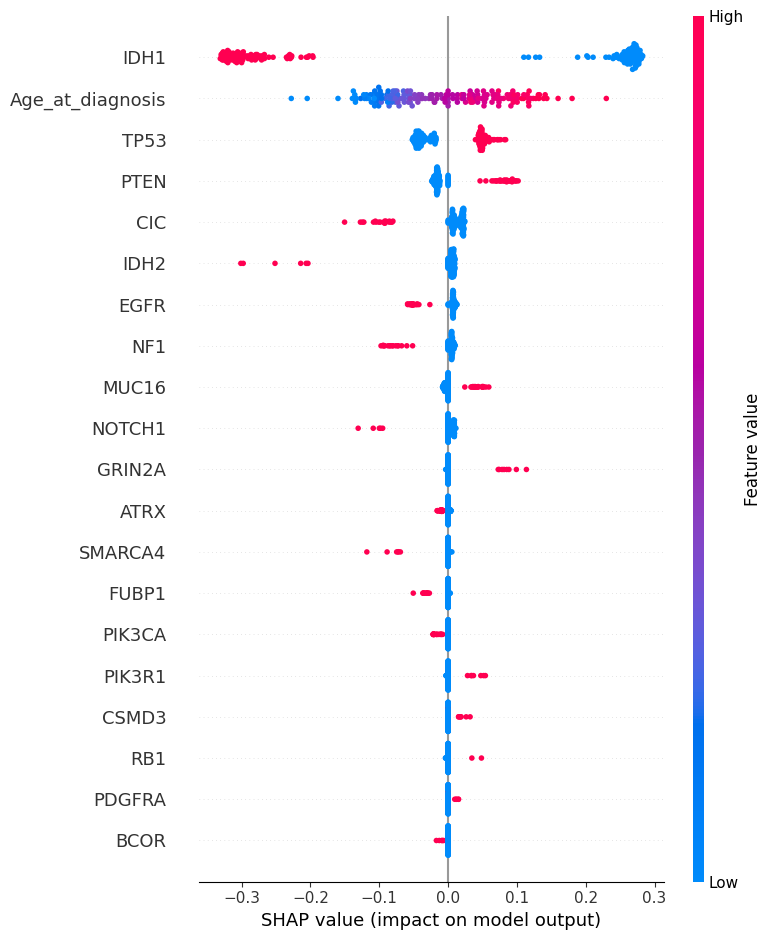

In [ ]:
shap.summary_plot(shap_values_lr[:, :, 1], X_test, show=False)

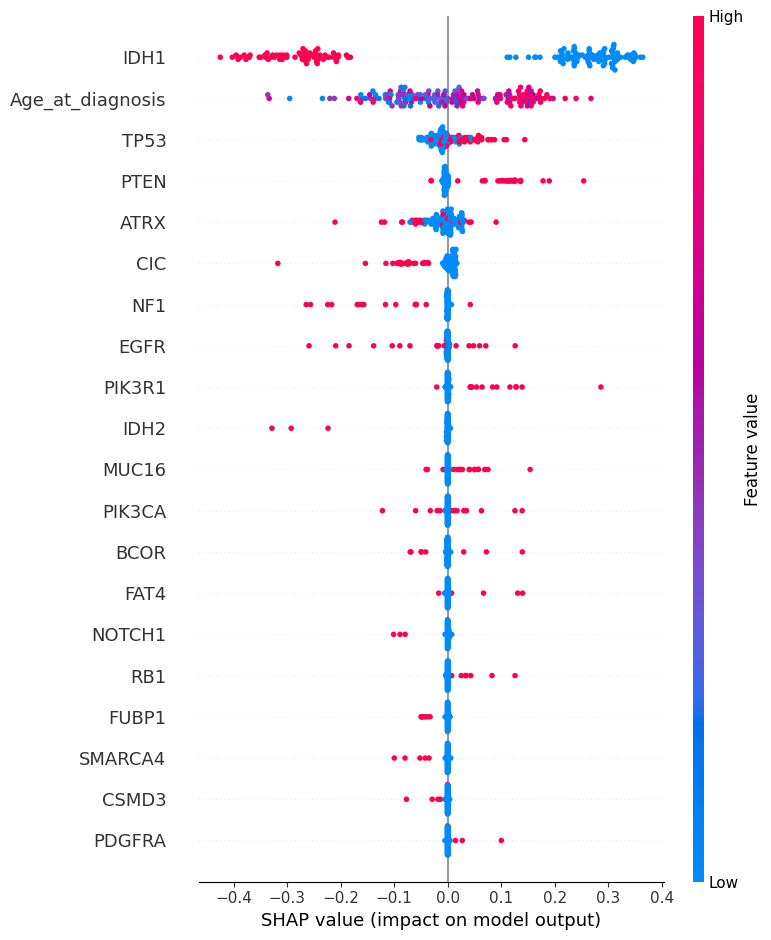

In [96]:
shap.summary_plot(shap_values_rf[:, :, 1], X_test2, show=False)

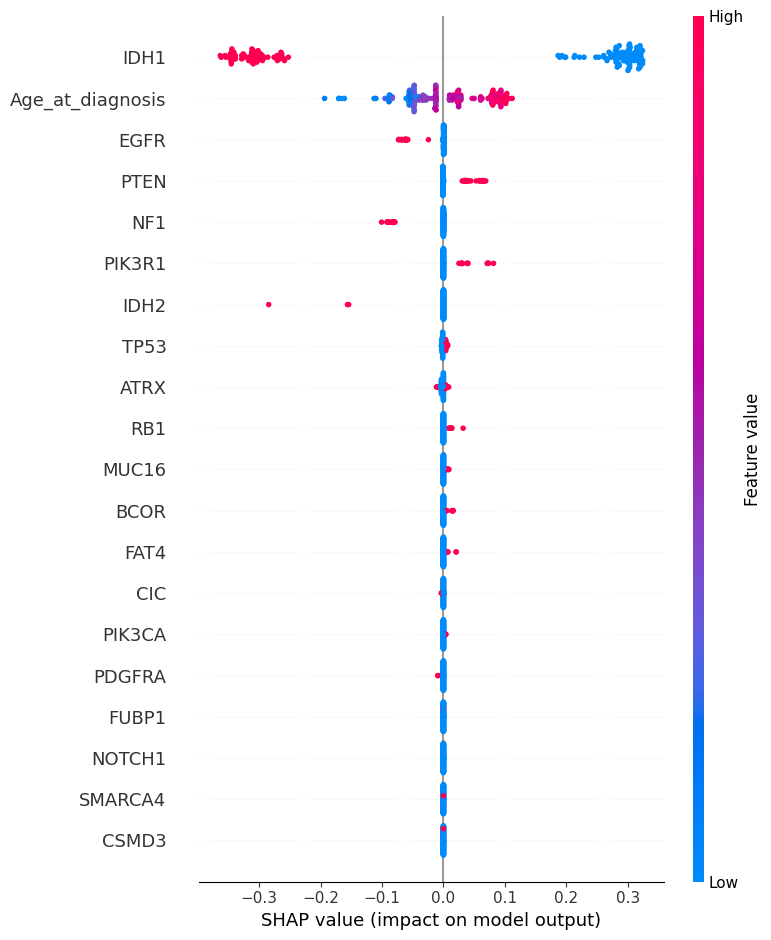

In [97]:
shap.summary_plot(shap_values_xgb[:, :, 1], X_test3, show=False)


In [82]:
weight_vector = {
    "IDH1":1.0,
    "IDH2":1.0,
    "ATRX":0.75,
    "TP53":0.75,
    "EGFR":0.5,
    "PTEN":0.5, 
    "NF1":0.5,
    "CIC":0.25, 
    "MUC16":0.25, 
    "PIK3CA":0.25, 
    "PIK3R1":0.25, 
    "FUBP1":0.25, 
    "RB1":0.25, 
    "NOTCH1":0.25, 
    "BCOR":0.25, 
    "CSMD3":0.25, 
    "SMARCA4":0.25, 
    "GRIN2A":0.25, 
    "FAT4":0.25, 
    "PDGFRA":0.25
}